[<img src="../quantumsymmetry_logo.png" alt="QuantumSymmetry" width="450"/>](https://github.com/dariopicozzi/quantumsymmetry)

> **Note:** if you are running this notebook on Google Colab, the next cell will install `quantumsymmetry` and its dependencies (this might take a few minutes):

In [1]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip -q install quantumsymmetry
    !pip -q install pylatexenc

# The ansatz, its pruning and its diagonal metric

Here we look inside a `MinimalCircuit`: how the active leaves classify the tree, what the pruned circuit looks like, how to read the state off the chart coordinates, and why the Fubini-Study metric is diagonal.

## Active, fixed and inactive nodes

Take the running example of the paper: $n = 4$ qubits with the five active basis states $S = \{0000, 0001, 0010, 0110, 1010\}$. Each internal node of the tree is classified by how many of its descendant leaves are active:

* **active** -- both sub-trees contain an active leaf, so the angle $\theta_i$ stays a free parameter;
* **fixed** -- only one sub-tree is occupied, so $\theta_i$ is pinned (all amplitude flows one way);
* **inactive** -- neither sub-tree is occupied, so the state does not depend on $\theta_i$ at all (a gauge direction the compiler removes).

In [2]:
from quantumsymmetry import MinimalCircuit

S = [0b0000, 0b0001, 0b0010, 0b0110, 0b1010]
mc = MinimalCircuit(num_qubits=4, support=S)

print('free parameters :', mc.num_parameters)
print('CNOTs           :', mc.circuit.count_ops().get('cx', 0))

free parameters : 4
CNOTs           : 10


Only four free angles survive, exactly the four *active* nodes of the tree -- against the 15 angles a generic four-qubit state would need. This is the ansatz's basic accounting: a tree over $K$ active leaves has exactly $K - 1$ active (branch) nodes, so it carries $K - 1$ free angles (here $5 - 1 = 4$), and the parameter count in every later notebook is this same $K - 1$. Let us draw the pruned circuit:

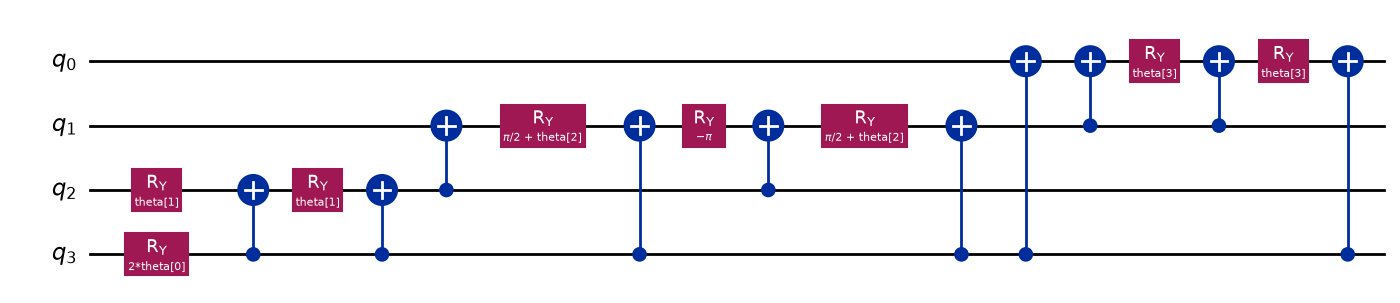

In [3]:
mc.circuit.draw(output='mpl', fold=-1)

## From angles to amplitudes

The `MinimalCircuit` is also a fast classical *chart*: it maps the angles $\boldsymbol\theta$ to the state vector $|\psi\rangle$ (and back) in $O(|S|)$ time, without simulating the circuit. The amplitudes are supported only on the active leaves, just as the tree promises.

In [4]:
import numpy as np

theta = np.array([0.3, -0.7, 1.1, 0.5])
psi = mc.statevector(theta)

for leaf in mc.support:
    print(f'{leaf:04b}: {psi[leaf]: .4f}')
print('norm:', np.linalg.norm(psi))

0000:  0.2909
0001:  0.1589
0010:  0.6512
0110: -0.6154
1010:  0.2955
norm: 0.9999999999999999


## The diagonal Fubini-Study metric

The geometry of the ansatz is captured by the inverse Fubini-Study metric $G^{-1}(\boldsymbol\theta)$. For the binary tree it is **diagonal**, and the reason is structural: each angle $\theta_i$ acts only on the two orthogonal sub-trees hanging off its own node, so moving one angle and moving another push the state in orthogonal directions and cannot couple. There are therefore no off-diagonal entries to estimate or invert, and geometry-aware updates are just an element-wise division. The values printed below are the diagonal of the *inverse* metric $G^{-1}$ -- the per-angle step lengths a natural-gradient update takes.

In [5]:
Ginv = mc.inverse_metric(theta)
print('shape          :', Ginv.shape)
off_diagonal = Ginv - np.diag(np.diag(Ginv))
print('max off-diag   :', np.abs(off_diagonal).max())
print('diagonal       :', np.round(np.diag(Ginv), 4))

shape          : (4, 4)
max off-diag   : 0.0
diagonal       : [1.     1.0957 1.873  9.1034]


## Exact gradients from a parameter-shift rule

Energy gradients on this ansatz are exact: each tree angle obeys a four-term parameter-shift rule (no finite-difference bias, no step size to tune). We check it against a finite difference on a toy energy $E(\boldsymbol\theta) = \langle\psi|Z_0|\psi\rangle$.

In [6]:
Z0 = np.array([1 if (i & 1) == 0 else -1 for i in range(2 ** mc.num_qubits)])

def energy(t):
    psi = mc.statevector(t)
    return float(np.real(np.vdot(psi, Z0 * psi)))

g_shift = mc.gradient(energy, theta, method='shift')
g_fd = mc.gradient(energy, theta, method='fd')
print('shift rule      :', np.round(g_shift, 6))
print('finite diff     :', np.round(g_fd, 6))
print('max difference  :', np.abs(g_shift - g_fd).max())

shift rule      : [ 0.031241 -0.085066  0.19843  -0.184869]
finite diff     : [ 0.031241 -0.085066  0.19843  -0.184869]
max difference  : 1.3228636830397988e-07


A diagonal metric and an exact gradient are all the geometry-aware algorithms need. In the next notebook we combine them into a natural-gradient VQE.

### The series

1. <a href="tree_01_welcome.ipynb" />Welcome: the binary-tree ansatz</a>
2. <a href="tree_02_ansatz_and_metric.ipynb" />The ansatz, its pruning and its diagonal metric</a>
3. <a href="tree_03_vqe.ipynb" />Natural-gradient VQE for molecules</a>
4. <a href="tree_04_dynamics.ipynb" />Real-time evolution</a>
5. <a href="tree_05_sampling.ipynb" />Sector-Haar sampling</a>
6. <a href="tree_06_dressing.ipynb" />Dressing the ansatz: a symmetry-adapted Schrieffer-Wolff transformation</a>
7. <a href="tree_07_spin.ipynb" />Spin adaptation: exact total spin on the tree</a>

<p style="text-align: left"> <a href="tree_01_welcome.ipynb" />&lt; Previous: Welcome: the binary-tree ansatz</a> </p>
<p style="text-align: right"> <a href="tree_03_vqe.ipynb" />Next: Natural-gradient VQE for molecules &gt;</a> </p>